In [1]:
!pip install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/pre-processed_data2701.csv')
df

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,Price
0,MAYCREATE® Beard Pencil Filler for Men Dual Ti...,beauty & health,Personal Care Appliances,https://m.media-amazon.com/images/W/IMAGERENDE...,https://www.amazon.in/MAYCREATE%C2%AE-Pencil-S...,3.6,6.0,598.0,899.0,598.0
1,Tash Hair Automatic Hair Curler Wireless Curli...,beauty & health,Personal Care Appliances,https://m.media-amazon.com/images/W/IMAGERENDE...,https://www.amazon.in/Tash-Hair-Automatic-Rech...,4.1,15.0,3499.0,3599.0,3499.0
2,VGR V-596 Professional Electric Hair Curling W...,beauty & health,Personal Care Appliances,https://m.media-amazon.com/images/W/IMAGERENDE...,https://www.amazon.in/VGR-V-596-Professional-E...,4.5,20.0,809.0,1380.0,809.0
3,BARBER Professional Stylish Hair Dryers for Wo...,beauty & health,Personal Care Appliances,https://m.media-amazon.com/images/W/IMAGERENDE...,https://www.amazon.in/BARBER-Professional-Styl...,4.1,303.0,700.0,999.0,700.0
4,"FEXMY® Electric Hair Straightener Brush,Men Qu...",beauty & health,Personal Care Appliances,https://m.media-amazon.com/images/W/IMAGERENDE...,https://www.amazon.in/Electric-Straightener-St...,3.0,17.0,349.0,1599.0,349.0
...,...,...,...,...,...,...,...,...,...,...
72331,Childplaymate g5_3_4_8 Dimmable 50 Watts LED P...,"tv, audio & cameras",Cameras,https://m.media-amazon.com/images/I/51745+VqL6...,https://www.amazon.in/Childplaymate-Dimmable-S...,3.9,310.0,1414.0,2799.0,1414.0
72332,CP PLUS CP-UNC-DS41PL3 4 MP Full HD IR Dome Ca...,"tv, audio & cameras",Cameras,https://m.media-amazon.com/images/I/31rVhEyCev...,https://www.amazon.in/CP-Plus-CP-UNC-DS41PL3-F...,3.2,6.0,4049.0,7700.0,3914.0
72333,Gosky 20-60x60 HD Spotting Scope with Tripod,"tv, audio & cameras",Cameras,https://m.media-amazon.com/images/I/71SSY9SXQh...,https://www.amazon.in/Gosky-20-60x60-Spotting-...,4.2,30.0,11990.0,22990.0,11990.0
72334,Ubersweet® 20mm DIV=1 CAT911 Eyepiece Micromet...,"tv, audio & cameras",Cameras,https://m.media-amazon.com/images/I/31sAK6M1TL...,https://www.amazon.in/Ubersweet%C2%AE-Micromet...,4.0,30.0,5249.0,10497.0,5249.0


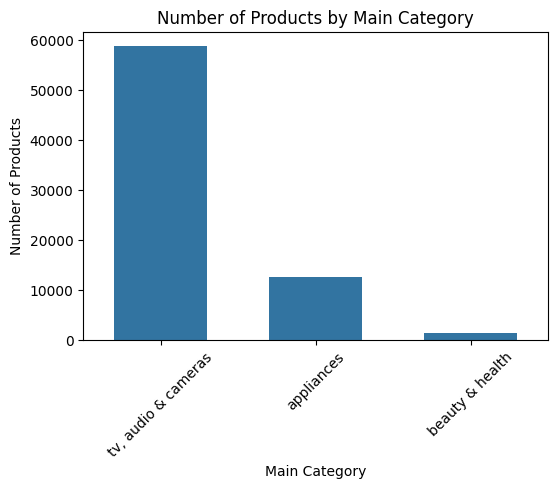

In [16]:
#Visualization 1: Bar Chart of Products by Main Category
plt.figure(figsize=(6,4))
main_category_count = df['main_category'].value_counts()

sns.barplot(x=main_category_count.index, y=main_category_count.values, width=0.6)

plt.title("Number of Products by Main Category")
plt.xlabel("Main Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()


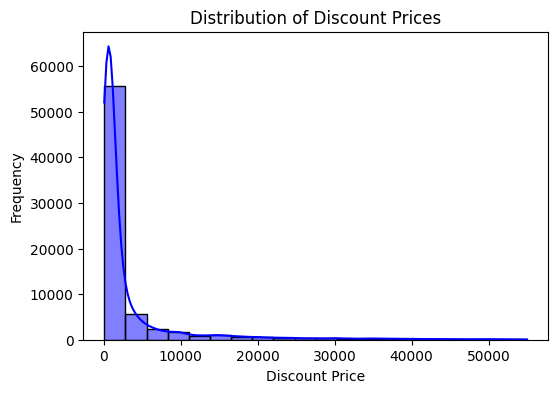

In [21]:
#Visualization 2: Distribution of Discount Prices
# Remove invalid or extreme outliers
q_low = df['discount_price'].quantile(0.01)
q_high = df['discount_price'].quantile(0.99)
df_filtered = df[(df['discount_price'] >= q_low) & (df['discount_price'] <= q_high)]

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.histplot(df_filtered['discount_price'], bins=20, kde=True, color='blue')
plt.title("Distribution of Discount Prices")
plt.xlabel("Discount Price")
plt.ylabel("Frequency")
plt.show()


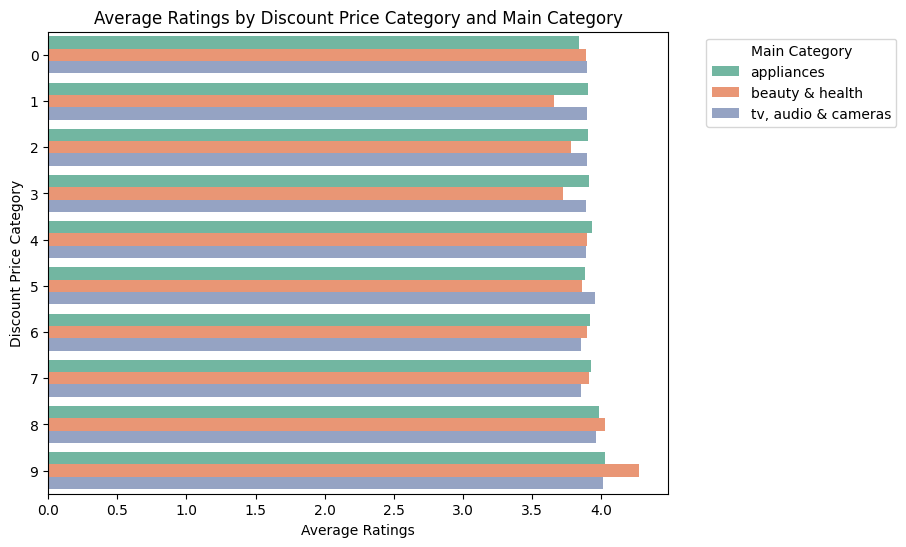

In [30]:
#Visualization 3: Ratings vs. Discount Price
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_filtered.groupby(['price_category', 'main_category'])['ratings'].mean().reset_index(),
    y="price_category",
    x="ratings",
    hue="main_category",
    palette="Set2",
    orient="h"
)

plt.title("Average Ratings by Discount Price Category and Main Category")
plt.xlabel("Average Ratings")
plt.ylabel("Discount Price Category")
plt.legend(title="Main Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()



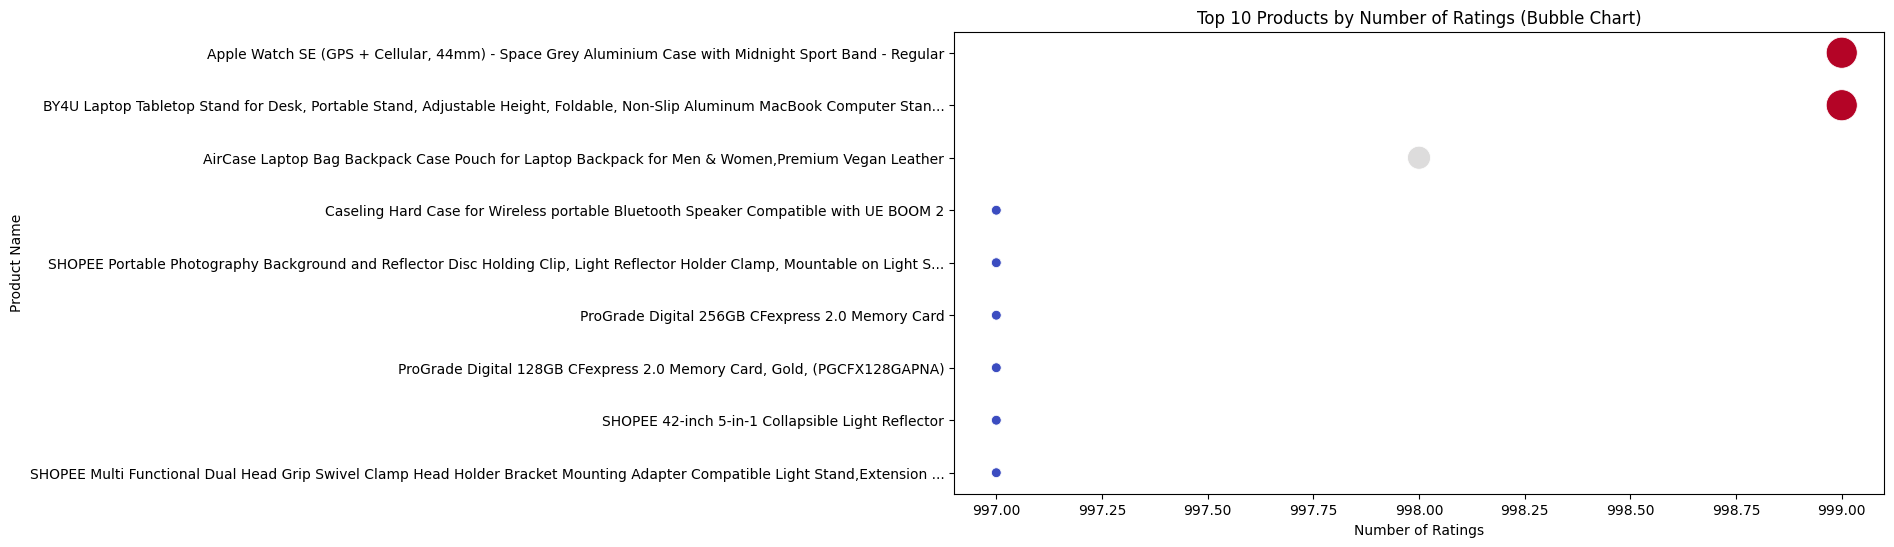

In [36]:
#Visualization 4: top products by number of ratings
plt.figure(figsize=(12, 6))

# Use 'no_of_ratings' for the size of the bubbles
sns.scatterplot(data=top_rated_products, x='no_of_ratings', y='name',
                size='no_of_ratings', sizes=(50, 500), hue='no_of_ratings', palette='coolwarm', legend=False)

plt.title("Top 10 Products by Number of Ratings (Bubble Chart)")
plt.xlabel("Number of Ratings")
plt.ylabel("Product Name")
plt.show()
